# Sistemas Inteligentes I
## Búsqueda no informada: BFS y DFS

**Autor:** Jairo I. Vélez B.

---

### Propósito de la práctica

En este notebook estudiaremos cómo resolver problemas mediante **búsqueda no informada**, es decir, estrategias que exploran el espacio de estados **sin disponer de una estimación sobre qué tan cerca se encuentra cada estado del objetivo**.

Al finalizar la práctica, el estudiante estará en capacidad de:

- Representar un problema mediante un **espacio de estados**.
- Implementar **Búsqueda en Anchura (BFS)**.
- Implementar **Búsqueda en Profundidad (DFS)**.
- Comparar el comportamiento de BFS y DFS.
- Aplicar estos algoritmos a problemas concretos.
- Analizar ventajas, limitaciones y costo de exploración.

## 1. Idea general: buscar sin información adicional

Un problema de búsqueda puede describirse mediante:

- **Estado inicial:** punto desde el cual comienza la búsqueda.
- **Estados:** configuraciones posibles del problema.
- **Acciones u operadores:** transformaciones permitidas entre estados.
- **Función sucesor:** determina qué estados pueden alcanzarse desde un estado dado.
- **Prueba de objetivo:** determina si se alcanzó la solución.

En la búsqueda no informada, el algoritmo **no conoce qué estado parece más prometedor**.  
Solo utiliza la estructura del espacio de búsqueda.

Dos estrategias fundamentales son:

- **BFS (Breadth-First Search):** explora por niveles.
- **DFS (Depth-First Search):** profundiza por una rama antes de retroceder.

## 2. Librerías utilizadas

Se utilizarán únicamente estructuras básicas de Python y matplotlib para algunas visualizaciones.

In [ ]:
from collections import deque
import matplotlib.pyplot as plt

print("Entorno listo.")

Entorno listo.


# 3. Primer espacio de estados: un grafo

Consideremos el siguiente grafo no ponderado:

- **Estado:** un nodo.
- **Estado inicial:** `A`.
- **Acciones:** desplazarse hacia un nodo adyacente.
- **Objetivo inicial de la demostración:** observar el orden de exploración.

La representación mediante un diccionario de listas de adyacencia es:

In [ ]:
grafo = {
    "A": ["B", "F"],
    "B": ["A", "C", "E"],
    "C": ["B", "D", "E"],
    "D": ["C", "E", "F"],
    "E": ["B", "C", "D"],
    "F": ["A", "D"],
}

grafo

{'A': ['B', 'F'],
 'B': ['A', 'C', 'E'],
 'C': ['B', 'D', 'E'],
 'D': ['C', 'E', 'F'],
 'E': ['B', 'C', 'D'],
 'F': ['A', 'D']}

## 4. Búsqueda en Anchura — BFS

BFS utiliza una **cola FIFO** (*First In, First Out*).

La idea es simple:

1. Insertar el estado inicial en la cola.
2. Extraer el primer estado de la cola.
3. Encontrar sus sucesores no visitados.
4. Insertarlos al final de la cola.
5. Repetir hasta terminar o encontrar el objetivo.

En grafos no ponderados, BFS puede encontrar un camino con el **menor número de aristas** desde el origen hasta el objetivo.

In [ ]:
def bfs(grafo, inicio):
    visitados = {inicio}
    cola = deque([inicio])
    recorrido = []

    while cola:
        nodo = cola.popleft()
        recorrido.append(nodo)

        for vecino in grafo[nodo]:
            if vecino not in visitados:
                visitados.add(vecino)
                cola.append(vecino)

    return recorrido


recorrido_bfs = bfs(grafo, "A")
print("Recorrido BFS:", recorrido_bfs)

Recorrido BFS: ['A', 'B', 'F', 'C', 'E', 'D']


### 4.1 BFS paso a paso

Para comprender el algoritmo conviene observar cómo cambian la **frontera** y el conjunto de **visitados**.

In [ ]:
def bfs_debug(grafo, inicio):
    visitados = {inicio}
    cola = deque([inicio])
    paso = 1

    while cola:
        print(f"\nPaso {paso}")
        print("Cola antes de expandir:", list(cola))
        print("Visitados:", sorted(visitados))

        nodo = cola.popleft()
        print("Nodo expandido:", nodo)

        for vecino in grafo[nodo]:
            if vecino not in visitados:
                visitados.add(vecino)
                cola.append(vecino)

        print("Cola después de expandir:", list(cola))
        paso += 1


bfs_debug(grafo, "A")


Paso 1
Cola antes de expandir: ['A']
Visitados: ['A']
Nodo expandido: A
Cola después de expandir: ['B', 'F']

Paso 2
Cola antes de expandir: ['B', 'F']
Visitados: ['A', 'B', 'F']
Nodo expandido: B
Cola después de expandir: ['F', 'C', 'E']

Paso 3
Cola antes de expandir: ['F', 'C', 'E']
Visitados: ['A', 'B', 'C', 'E', 'F']
Nodo expandido: F
Cola después de expandir: ['C', 'E', 'D']

Paso 4
Cola antes de expandir: ['C', 'E', 'D']
Visitados: ['A', 'B', 'C', 'D', 'E', 'F']
Nodo expandido: C
Cola después de expandir: ['E', 'D']

Paso 5
Cola antes de expandir: ['E', 'D']
Visitados: ['A', 'B', 'C', 'D', 'E', 'F']
Nodo expandido: E
Cola después de expandir: ['D']

Paso 6
Cola antes de expandir: ['D']
Visitados: ['A', 'B', 'C', 'D', 'E', 'F']
Nodo expandido: D
Cola después de expandir: []


# 5. Búsqueda en Profundidad — DFS

DFS utiliza una **pila LIFO** (*Last In, First Out*).

Su comportamiento es diferente:

1. Inserta el estado inicial en la pila.
2. Extrae el estado ubicado en la parte superior.
3. Agrega sus sucesores no visitados.
4. Continúa profundizando por una rama.
5. Cuando no puede avanzar, retrocede implícitamente mediante la pila.

> El orden en el que se generan los sucesores puede cambiar el recorrido obtenido.

In [ ]:
def dfs(grafo, inicio):
    visitados = {inicio}
    pila = [inicio]
    recorrido = []

    while pila:
        nodo = pila.pop()
        recorrido.append(nodo)

        for vecino in (grafo[nodo]):
            if vecino not in visitados:
                visitados.add(vecino)
                pila.append(vecino)

    return recorrido


recorrido_dfs = dfs(grafo, "A")
print("Recorrido DFS:", recorrido_dfs)

Recorrido DFS: ['A', 'F', 'D', 'E', 'C', 'B']


### 5.1 DFS paso a paso

In [ ]:
def dfs_debug(grafo, inicio):
    visitados = {inicio}
    pila = [inicio]
    paso = 1

    while pila:
        print(f"\nPaso {paso}")
        print("Pila antes de expandir:", pila)
        print("Visitados:", sorted(visitados))

        nodo = pila.pop()
        print("Nodo expandido:", nodo)

        for vecino in (grafo[nodo]):
            if vecino not in visitados:
                visitados.add(vecino)
                pila.append(vecino)

        print("Pila después de expandir:", pila)
        paso += 1


dfs_debug(grafo, "A")


Paso 1
Pila antes de expandir: ['A']
Visitados: ['A']
Nodo expandido: A
Pila después de expandir: ['B', 'F']

Paso 2
Pila antes de expandir: ['B', 'F']
Visitados: ['A', 'B', 'F']
Nodo expandido: F
Pila después de expandir: ['B', 'D']

Paso 3
Pila antes de expandir: ['B', 'D']
Visitados: ['A', 'B', 'D', 'F']
Nodo expandido: D
Pila después de expandir: ['B', 'C', 'E']

Paso 4
Pila antes de expandir: ['B', 'C', 'E']
Visitados: ['A', 'B', 'C', 'D', 'E', 'F']
Nodo expandido: E
Pila después de expandir: ['B', 'C']

Paso 5
Pila antes de expandir: ['B', 'C']
Visitados: ['A', 'B', 'C', 'D', 'E', 'F']
Nodo expandido: C
Pila después de expandir: ['B']

Paso 6
Pila antes de expandir: ['B']
Visitados: ['A', 'B', 'C', 'D', 'E', 'F']
Nodo expandido: B
Pila después de expandir: []


## 6. BFS vs. DFS

| Característica | BFS | DFS |
|---|---|---|
| Estructura principal | Cola | Pila |
| Estrategia | Explora por niveles | Profundiza por ramas |
| Camino mínimo en grafo no ponderado | Sí | No necesariamente |
| Uso de memoria | Puede ser alto | Suele ser menor |
| Riesgo principal | Explosión de memoria | Profundizar demasiado |
| ¿Usa heurística? | No | No |

### Pregunta para discutir

**¿Existe un único recorrido BFS o DFS para un grafo?**

No necesariamente. El resultado puede cambiar según el orden en que se generen o almacenen los sucesores.

# 7. Problema 1: encontrar la salida de un laberinto

Usaremos `0` para representar una celda transitable y `1` para representar una pared.

Modelado:

- **Estado:** `(fila, columna)`.
- **Estado inicial:** `(0, 0)`.
- **Objetivo:** `(4, 4)`.
- **Acciones:** arriba, abajo, izquierda y derecha.
- **Restricción:** no atravesar paredes ni salir del tablero.

In [ ]:
laberinto = [
    [0, 1, 0, 0, 0],
    [0, 1, 0, 1, 0],
    [0, 0, 0, 1, 0],
    [0, 1, 0, 1, 1],
    [0, 0, 0, 0, 0],
]

INICIO = (0, 0)
OBJETIVO = (4, 4)
MOVIMIENTOS = [(1, 0), (-1, 0), (0, 1), (0, -1)]

In [ ]:
def sucesores_laberinto(laberinto, posicion):
    filas = len(laberinto)
    columnas = len(laberinto[0])
    f, c = posicion

    sucesores = []

    for df, dc in MOVIMIENTOS:
        nf, nc = f + df, c + dc

        if (
            0 <= nf < filas
            and 0 <= nc < columnas
            and laberinto[nf][nc] == 0
        ):
            sucesores.append((nf, nc))

    return sucesores

## 7.1 Resolver el laberinto con BFS

Además del camino, contabilizaremos cuántos estados fueron descubiertos.

In [ ]:
def bfs_camino_laberinto(laberinto, inicio, objetivo):
    if laberinto[inicio[0]][inicio[1]] == 1:
        return None
    if laberinto[objetivo[0]][objetivo[1]] == 1:
        return None

    cola = deque([(inicio, [inicio])])
    visitados = {inicio}

    while cola:
        posicion, camino = cola.popleft()

        if posicion == objetivo:
            return {
                "camino": camino,
                "explorados": len(visitados),
            }

        for nuevo in sucesores_laberinto(laberinto, posicion):
            if nuevo not in visitados:
                visitados.add(nuevo)
                cola.append((nuevo, camino + [nuevo]))

    return None


resultado_bfs = bfs_camino_laberinto(laberinto, INICIO, OBJETIVO)
resultado_bfs

{'camino': [(0, 0),
  (1, 0),
  (2, 0),
  (3, 0),
  (4, 0),
  (4, 1),
  (4, 2),
  (4, 3),
  (4, 4)],
 'explorados': 16}

## 7.2 Resolver el mismo laberinto con DFS

In [ ]:
def dfs_camino_laberinto(laberinto, inicio, objetivo):
    if laberinto[inicio[0]][inicio[1]] == 1:
        return None
    if laberinto[objetivo[0]][objetivo[1]] == 1:
        return None

    pila = [(inicio, [inicio])]
    visitados = {inicio}

    while pila:
        posicion, camino = pila.pop()

        if posicion == objetivo:
            return {
                "camino": camino,
                "explorados": len(visitados),
            }

        for nuevo in (sucesores_laberinto(laberinto, posicion)):
            if nuevo not in visitados:
                visitados.add(nuevo)
                pila.append((nuevo, camino + [nuevo]))

    return None


resultado_dfs = dfs_camino_laberinto(laberinto, INICIO, OBJETIVO)
resultado_dfs

{'camino': [(0, 0),
  (1, 0),
  (2, 0),
  (2, 1),
  (2, 2),
  (3, 2),
  (4, 2),
  (4, 3),
  (4, 4)],
 'explorados': 18}

## 7.3 Visualización del camino

La visualización permite comparar no solo si ambos algoritmos encuentran una solución, sino **qué tipo de camino producen**.

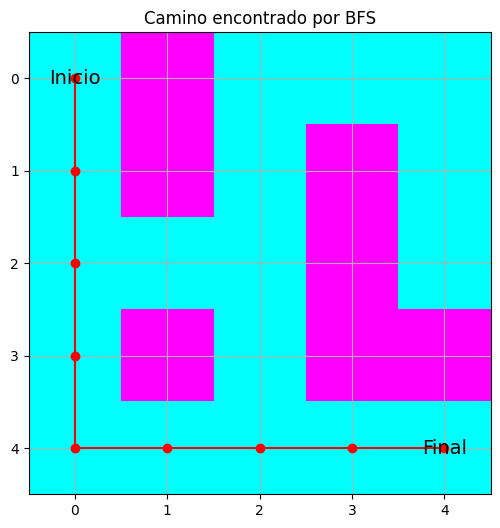

In [ ]:
def mostrar_laberinto(laberinto, camino=None, inicio=None, objetivo=None, titulo="Laberinto"):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(laberinto,cmap='cool')

    if camino:
        xs = [c for f, c in camino]
        ys = [f for f, c in camino]
        ax.plot(xs, ys, c='red', marker="o")

    if inicio is not None:
        ax.text(inicio[1], inicio[0], "Inicio", ha="center", va="center", fontsize=14)
    if objetivo is not None:
        ax.text(objetivo[1], objetivo[0], "Final", ha="center", va="center", fontsize=14)

    ax.set_xticks(range(len(laberinto[0])))
    ax.set_yticks(range(len(laberinto)))
    ax.set_title(titulo)
    ax.grid(True)
    plt.show()


mostrar_laberinto(
    laberinto,
    resultado_bfs["camino"],
    INICIO,
    OBJETIVO,
    "Camino encontrado por BFS"
)

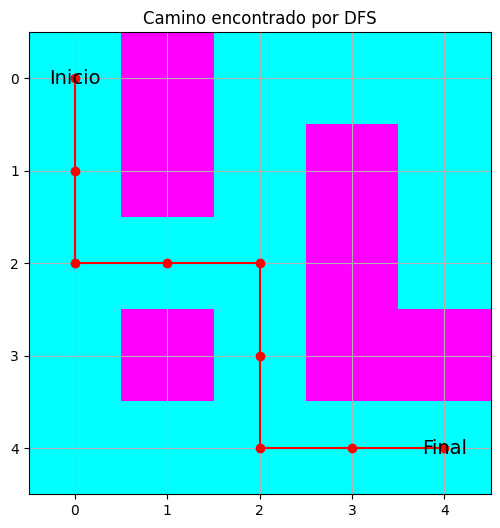

In [ ]:
mostrar_laberinto(
    laberinto,
    resultado_dfs["camino"],
    INICIO,
    OBJETIVO,
    "Camino encontrado por DFS"
)

## 7.4 Comparación experimental

In [ ]:
comparacion = {
    "BFS": {
        "longitud_camino": len(resultado_bfs["camino"]) - 1,
        "explorados": resultado_bfs["explorados"],
    },
    "DFS": {
        "longitud_camino": len(resultado_dfs["camino"]) - 1,
        "explorados": resultado_dfs["explorados"],
    },
}

comparacion

{'BFS': {'longitud_camino': 8, 'explorados': 16},
 'DFS': {'longitud_camino': 8, 'explorados': 18}}

### Preguntas de análisis

1. ¿Ambos algoritmos encontraron una solución?
2. ¿Los caminos tienen la misma longitud?
3. ¿Cuál exploró más estados?
4. ¿Por qué BFS puede garantizar el camino con menor número de movimientos en este problema?
5. ¿Cambiaría el resultado de DFS si modificamos el orden de `MOVIMIENTOS`?

# 8. Problema 2: recipientes de agua

Se dispone de:

- Un recipiente **M** con capacidad de 5 litros.
- Un recipiente **N** con capacidad de 3 litros.
- Una fuente ilimitada de agua.
- El objetivo es obtener **exactamente 4 litros**.

## Representación del estado

Un estado será una tupla:

\[
(m,n)
\]

donde:

- `m` = cantidad de agua en el recipiente M.
- `n` = cantidad de agua en el recipiente N.

Estado inicial:

\[
(0,0)
\]

### Operadores

1. Llenar M.
2. Llenar N.
3. Vaciar M.
4. Vaciar N.
5. Verter N → M.
6. Verter M → N.

In [ ]:
def sucesores_recipientes(estado, M, N):
    m, n = estado

    return [
        ((M, n), "Llenar M"),
        ((m, N), "Llenar N"),
        ((0, n), "Vaciar M"),
        ((m, 0), "Vaciar N"),

        # Verter N -> M
        (
            (
                min(M, m + n),
                max(0, m + n - M)
            ),
            "Verter N → M"
        ),

        # Verter M -> N
        (
            (
                max(0, m + n - N),
                min(N, m + n)
            ),
            "Verter M → N"
        ),
    ]

In [ ]:
def bfs_recipientes(M, N, objetivo):
    inicio = (0, 0)
    cola = deque([(inicio, [inicio], [])])
    visitados = {inicio}

    while cola:
        estado, camino, acciones = cola.popleft()

        if objetivo in estado:
            return {
                "estados": camino,
                "acciones": acciones,
                "explorados": len(visitados),
            }

        for nuevo_estado, accion in sucesores_recipientes(estado, M, N):
            if nuevo_estado not in visitados:
                visitados.add(nuevo_estado)
                cola.append(
                    (
                        nuevo_estado,
                        camino + [nuevo_estado],
                        acciones + [accion],
                    )
                )

    return None


solucion_recipientes = bfs_recipientes(5, 3, 4)
solucion_recipientes

{'estados': [(0, 0), (5, 0), (2, 3), (2, 0), (0, 2), (5, 2), (4, 3)],
 'acciones': ['Llenar M',
  'Verter M → N',
  'Vaciar N',
  'Verter M → N',
  'Llenar M',
  'Verter M → N'],
 'explorados': 14}

## 8.1 Mostrar la solución paso a paso

In [ ]:
def mostrar_solucion_recipientes(solucion):
    if solucion is None:
        print("No se encontró solución.")
        return

    estados = solucion["estados"]
    acciones = solucion["acciones"]

    print("Estado inicial:", estados[0])

    for i, accion in enumerate(acciones, start=1):
        print(f"{i}. {accion:15s} -> {estados[i]}")

    print("\nEstados explorados:", solucion["explorados"])


mostrar_solucion_recipientes(solucion_recipientes)

Estado inicial: (0, 0)
1. Llenar M        -> (5, 0)
2. Verter M → N    -> (2, 3)
3. Vaciar N        -> (2, 0)
4. Verter M → N    -> (0, 2)
5. Llenar M        -> (5, 2)
6. Verter M → N    -> (4, 3)

Estados explorados: 14


### Preguntas de análisis

1. ¿Por qué el problema de los recipientes puede representarse como un grafo?
2. ¿Cuántos estados posibles existen como máximo?
3. ¿Qué representa una arista entre dos estados?
4. ¿Por qué BFS es una estrategia apropiada si queremos minimizar el número de operaciones?
5. ¿Qué cambiaría si cada operación tuviera un costo distinto?

# 9. Reto final: el 8-puzzle

El 8-puzzle consiste en un tablero de `3 × 3` con ocho fichas y una casilla vacía.

Cada configuración del tablero representa un **estado**.

El objetivo es transformar un estado inicial en un estado objetivo moviendo una ficha adyacente hacia la posición vacía.

Este problema será especialmente útil más adelante, cuando comparemos **búsqueda no informada** con **búsqueda informada y A\***.

In [ ]:
estado_inicial = (
    1, 2, 3,
    4, 5, 0,
    6, 8, 7,
)

estado_objetivo = (
    1, 2, 3,
    4, 5, 6,
    7, 8, 0,
)

estado_inicial, estado_objetivo

((1, 2, 3, 4, 5, 0, 6, 8, 7), (1, 2, 3, 4, 5, 6, 7, 8, 0))

## 9.1 Generación de sucesores

El `0` representa la casilla vacía.

La siguiente función genera todos los estados alcanzables mediante **un movimiento válido**.

In [ ]:
def sucesores_8_puzzle(estado):
    estado = list(estado)
    indice_cero = estado.index(0)

    fila, columna = divmod(indice_cero, 3)

    movimientos = [
        (-1, 0),
        (1, 0),
        (0, -1),
        (0, 1),
    ]

    sucesores = []

    for df, dc in movimientos:
        nf, nc = fila + df, columna + dc

        if 0 <= nf < 3 and 0 <= nc < 3:
            nuevo_indice = nf * 3 + nc
            nuevo = estado.copy()

            nuevo[indice_cero], nuevo[nuevo_indice] = (
                nuevo[nuevo_indice],
                nuevo[indice_cero],
            )

            sucesores.append(tuple(nuevo))

    return sucesores


sucesores_8_puzzle(estado_inicial)

[(1, 2, 0, 4, 5, 3, 6, 8, 7),
 (1, 2, 3, 4, 5, 7, 6, 8, 0),
 (1, 2, 3, 4, 0, 5, 6, 8, 7)]

## 9.2 Ejercicio

Implemente una función:

```python
bfs_8_puzzle(estado_inicial, estado_objetivo)
```

que devuelva:

- El camino desde el estado inicial hasta el objetivo.
- El número de movimientos.
- La cantidad de estados explorados.

### Restricciones

- Utilice BFS.
- Evite visitar dos veces el mismo estado.
- No utilice ninguna heurística.

> **Pregunta:** ¿Qué problema aparece cuando el estado inicial se encuentra muy lejos del objetivo?

In [ ]:
def bfs_8_puzzle(estado_inicial, estado_objetivo):
    cola = deque([estado_inicial])
    padre = {estado_inicial: None}

    while cola:
        estado = cola.popleft()

        if estado == estado_objetivo:
            # reconstruir el camino desde el objetivo hacia el inicio
            camino = []
            actual = estado
            while actual is not None:
                camino.append(actual)
                actual = padre[actual]
            camino.reverse()
            return {
                "camino": camino,
                "movimientos": len(camino) - 1,
                "explorados": len(padre),
            }

        for sucesor in sucesores_8_puzzle(estado):
            if sucesor not in padre:
                padre[sucesor] = estado
                cola.append(sucesor)

    return None


def mostrar_tablero(estado):
    for i in range(0, 9, 3):
        fila = ""
        for x in estado[i:i+3]:
            if x == 0:
                fila += "_ "
            else:
                fila += str(x) + " "
        print(fila)
    print()


def mostrar_solucion_8_puzzle(solucion):
    if solucion is None:
        print("No se encontró solución.")
        return
    print("Movimientos:", solucion["movimientos"])
    print("Estados explorados:", solucion["explorados"])
    print()
    for k, estado in enumerate(solucion["camino"]):
        print(f"Paso {k}:")
        mostrar_tablero(estado)


### Prueba con el estado inicial del notebook

Al ejecutar `bfs_8_puzzle(estado_inicial, estado_objetivo)` con el estado inicial definido en la sección 9, la búsqueda no encuentra solución. Esto ocurre porque no todos los estados del 8-puzzle son alcanzables entre sí: el objetivo está en una componente distinta a la del estado inicial.

Al ser BFS un algoritmo **completo**, si agota la frontera sin encontrar el objetivo podemos afirmar con certeza que no existe solución.

In [ ]:
solucion_8 = bfs_8_puzzle(estado_inicial, estado_objetivo)
mostrar_solucion_8_puzzle(solucion_8)


### Prueba con estados iniciales resolubles

Se toma un estado a **dos movimientos** del objetivo (las fichas 5 y 8 desplazadas). También se prueba un estado a distancia media y uno de los estados **más lejanos posibles** (31 movimientos, el diámetro del espacio de estados del 8-puzzle).

In [ ]:
import time

casos = {
    "cercano (2 mov.)":  (1, 2, 3, 4, 0, 6, 7, 5, 8),
    "medio (6 mov.)":    (4, 1, 3, 7, 2, 6, 0, 5, 8),
    "lejano (31 mov.)":  (8, 6, 7, 2, 5, 4, 3, 0, 1),
}

print(f"{'Caso':<20}{'Movimientos':>12}{'Explorados':>12}{'Tiempo (s)':>12}")
for nombre, inicio in casos.items():
    t0 = time.time()
    sol = bfs_8_puzzle(inicio, estado_objetivo)
    dt = round(time.time() - t0, 3)
    print(f"{nombre:<20}{sol['movimientos']:>12}{sol['explorados']:>12}{dt:>12}")


In [ ]:
# Solución detallada del caso cercano
mostrar_solucion_8_puzzle(bfs_8_puzzle(casos["cercano (2 mov.)"], estado_objetivo))


Movimientos: 2
Estados explorados: 9 

Paso 0:
1 2 3
4 _ 6
7 5 8

Paso 1:
1 2 3
4 5 6
7 _ 8

Paso 2:
1 2 3
4 5 6
7 8 _



### Respuesta: ¿qué problema aparece cuando el estado inicial está muy lejos del objetivo?

BFS explora por niveles: antes de mirar un estado a profundidad *d+1* tiene que haber generado todos los estados a profundidad *d*. En el 8-puzzle esto hace que el número de estados crezca muy rápido con la profundidad de la solución.

Se ve en la tabla anterior:

- 2 movimientos → 9 estados explorados.
- 6 movimientos → 53 estados.
- 31 movimientos → 181 439 estados (casi todo el espacio alcanzable).

Los problemas concretos son:

1. **Memoria:** hay que guardar toda la frontera y los visitados. Para el 8-puzzle todavía cabe, pero para el 15-puzzle sería inviable.
2. **Tiempo:** el número total de estados generados crece exponencialmente con la profundidad, aunque cada operación sea barata.
3. **No hay poda:** BFS trata igual un estado que está a un movimiento del objetivo y otro que está a treinta; solo distingue por nivel.

Esto motiva la siguiente unidad: usar una **heurística** para priorizar los estados más prometedores (búsqueda voraz, A*).

# 10. Conclusiones

En esta práctica observamos que:

- Un problema puede modelarse mediante **estados, acciones y una condición objetivo**.
- BFS y DFS son estrategias de búsqueda **no informada**.
- BFS explora por niveles y utiliza una cola.
- DFS profundiza por ramas y utiliza una pila.
- BFS puede encontrar caminos mínimos cuando todas las acciones tienen el mismo costo.
- DFS puede requerir menos memoria, pero no garantiza un camino mínimo.
- El tamaño del espacio de estados puede hacer que una búsqueda no informada sea muy costosa.

---

## Pregunta

Si el espacio de búsqueda contiene millones de estados:

> **¿Podríamos utilizar información del problema para decidir qué estados parecen más prometedores y explorarlos primero?**

Esa pregunta nos lleva a la **búsqueda informada y las heurísticas**.

# 11. Taller para estudiar

1. Modifique el orden de los movimientos del laberinto y compare el comportamiento de DFS.
2. Construya un laberinto de al menos `10 × 10` y compare BFS y DFS en:
   - longitud del camino,
   - estados explorados.
3. Modifique el problema de los recipientes para capacidades diferentes y determine si existe solución.
4. Complete la implementación BFS del 8-puzzle.
5. Explique, con sus propias palabras, por qué BFS y DFS se consideran algoritmos de búsqueda **no informada**.

### Uso de IA generativa

Si utiliza una herramienta de IA generativa en esta actividad, indique:

- herramienta utilizada,
- propósito de uso,
- partes de la solución en las que fue empleada.

Recuerde: usted debe estar en capacidad de **explicar y defender completamente** el código y las respuestas entregadas.

## 11.1 Orden de los movimientos y comportamiento de DFS

DFS toma siempre el último sucesor que entró en la pila. Como los sucesores se generan siguiendo `MOVIMIENTOS`, el orden de esa lista determina **qué rama se explora primero**.

In [ ]:
def dfs_laberinto_con_orden(laberinto, inicio, objetivo, orden):
    global MOVIMIENTOS
    MOVIMIENTOS = orden
    return dfs_camino_laberinto(laberinto, inicio, objetivo)


ordenes = {
    "abajo, arriba, der, izq (original)": [(1, 0), (-1, 0), (0, 1), (0, -1)],
    "der, abajo, izq, arriba":            [(0, 1), (1, 0), (0, -1), (-1, 0)],
    "arriba, izq, abajo, der":            [(-1, 0), (0, -1), (1, 0), (0, 1)],
    "izq, der, arriba, abajo":            [(0, -1), (0, 1), (-1, 0), (1, 0)],
}

comparacion_ordenes = {}
for nombre, orden in ordenes.items():
    r = dfs_laberinto_con_orden(laberinto, INICIO, OBJETIVO, orden)
    comparacion_ordenes[nombre] = {
        "longitud_camino": len(r["camino"]) - 1,
        "explorados": r["explorados"],
    }

# dejar el orden original para no romper el resto del notebook
MOVIMIENTOS = [(1, 0), (-1, 0), (0, 1), (0, -1)]

comparacion_ordenes


**Análisis.** solo existe **un camino** entre `(0,0)` y `(4,4)` , por lo que la longitud del camino encontrado por DFS es  8, igual que BFS, cambia es el **número de estados explorados**: cuando el orden prioriza los movimientos que "apuntan" hacia el objetivo, DFS entra en los callejones sin salida más tarde y visita menos celdas (12 frente a 18)